# Declaration of Originality

![image.png](attachment:image.png)

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Jared Nathaniel John (2401776F)
* Tutorial Group                : PC05
* Tutor						    : Dr Kian Eng Ong
* Submission Date               : 11 February 2026



**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import sklearn
from sklearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Business Understanding
<h2>Problem Statement</h2>
<h5>Cardiovascular diseases (CVDs) are the leading cause of death globally, taking an estimated 17.9 million lives each year. Early identification of individuals at high risk of heart disease is critical for medical professionals to implement preventative care, lifestyle changes, and medical interventions that can save lives and reduce the burden on healthcare systems.</h5>

## Project Objective
The primary goal of this project is to develop a predictive machine learning model that classifies whether an individual has a history of heart disease based on various health indicators. This is a classification task where the target variable is Heart_Disease (Yes/No).

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
## Read *.csv file into pandas DataFrame
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/CVD_cleaned.csv'
df = pd.read_csv(FILE_PATH)
df


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168.0,81.65,29.05,No,4.0,30.0,8.0,0.0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180.0,69.85,21.48,No,8.0,15.0,60.0,4.0
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157.0,61.23,24.69,Yes,4.0,40.0,8.0,4.0
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183.0,79.38,23.73,No,3.0,30.0,12.0,0.0


## 2.2 Summary Statistics

In [4]:
## Shape of the Dataframe
df.shape

(308854, 19)

In [5]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

In [6]:
# Check for any  missing values
df.isnull().sum()

,0
General_Health,0
Checkup,0
Exercise,0
Heart_Disease,0
Skin_Cancer,0
Other_Cancer,0
Depression,0
Diabetes,0
Arthritis,0
Sex,0


In [7]:
## Describe data distribution
df.describe(include = 'all')

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854.000000,308854.000000,308854.000000,308854,308854.000000,308854.000000,308854.000000,308854.000000
unique,5,5,2,2,2,2,2,4,2,2,13,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
top,Very Good,Within the past year,Yes,No,No,No,No,No,No,Female,65-69,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
freq,110395,239371,239381,283883,278860,278976,246953,259141,207783,160196,33434,NaN,NaN,NaN,183590,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.615249,83.588655,28.626211,NaN,5.096366,29.835200,15.110441,6.296616
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.658026,21.343210,6.522323,NaN,8.199763,24.875735,14.926238,8.582954
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.000000,24.950000,12.020000,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.000000,68.040000,24.210000,NaN,0.000000,12.000000,4.000000,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.000000,81.650000,27.440000,NaN,1.000000,30.000000,12.000000,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178.000000,95.250000,31.850000,NaN,6.000000,30.000000,20.000000,8.000000


## Summary of Data Understanding from Summary Statistics

The dataset comprises of **308,854 entries** and **19 features**, with no missing values across any column. The features consist of **12 categorical** (object type) and **7 numerical** (float64 type) variables.

### Key observations include:

*   **Target Variable (`Heart_Disease`)**: It is a categorical variable with 'No' being the **dominating** class, indicating a significant **class imbalance** that will need to be addressed during model training.
*   **Categorical Features**: Variables like `General_Health`, `Checkup`, `Diabetes`, and `Age_Category` have multiple unique values beyond a simple binary choice. It was also noted that the `Diabetes` column, which is expected to be binary (Yes/No), currently has more than two unique values, suggesting the presence of abnormal values that will require **imputation or removal**. These categorical features will also require **one-hot encoding** to convert them into a numerical format suitable for machine learning models.
*   **Numerical Features**: Columns such as `Height_(cm)`, `Weight_(kg)`, and `BMI`, along with the consumption-related features (`Alcohol_Consumption`, `Fruit_Consumption`, etc.), show a wide range of values and potential **outliers**, as indicated by the spread between min/max and the quartile ranges. This suggests that **feature scaling**  and  **outlier treatment** may be necessary for optimal model performance.




## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

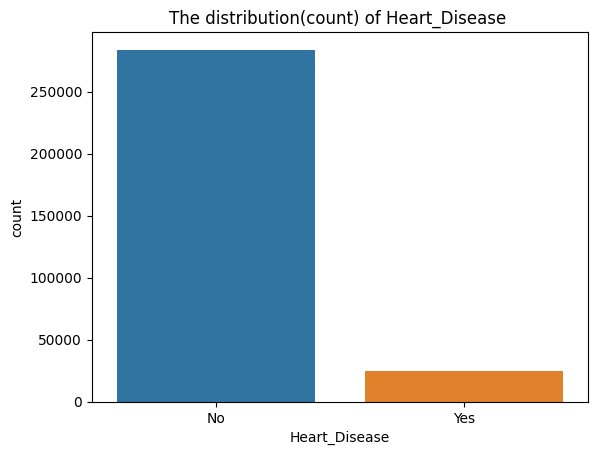

In [8]:
## Understanding distribution of target (Heart_Disease)
sns.countplot(x ='Heart_Disease', hue= 'Heart_Disease', data = df)
plt.title('The distribution(count) of Heart_Disease ')
plt.show()

<Figure size 600x400 with 0 Axes>

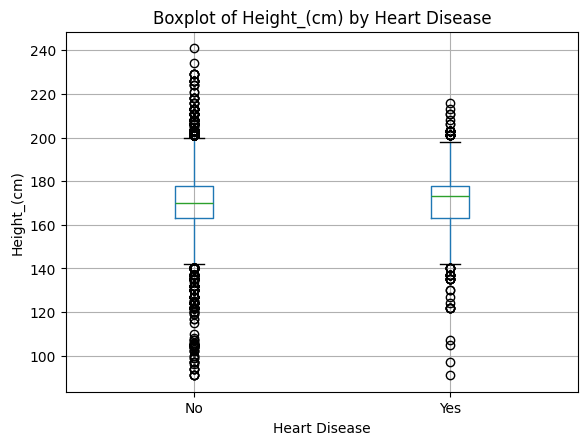

<Figure size 600x400 with 0 Axes>

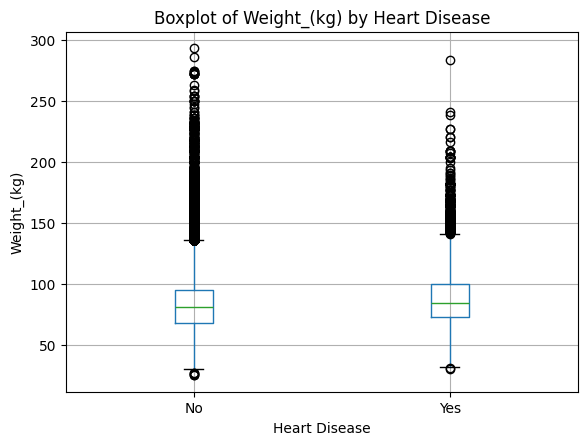

<Figure size 600x400 with 0 Axes>

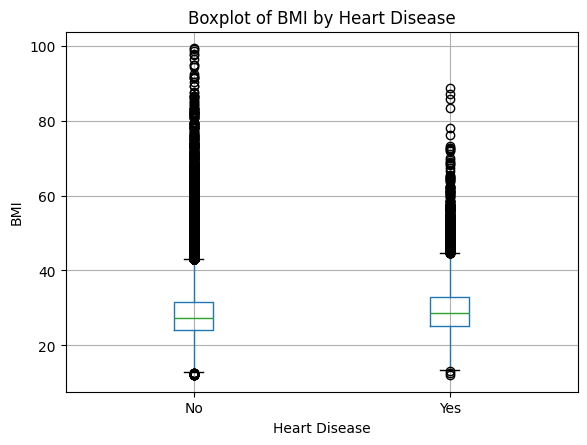

<Figure size 600x400 with 0 Axes>

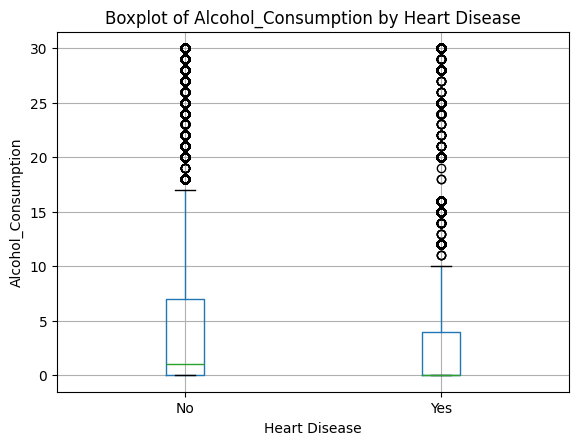

<Figure size 600x400 with 0 Axes>

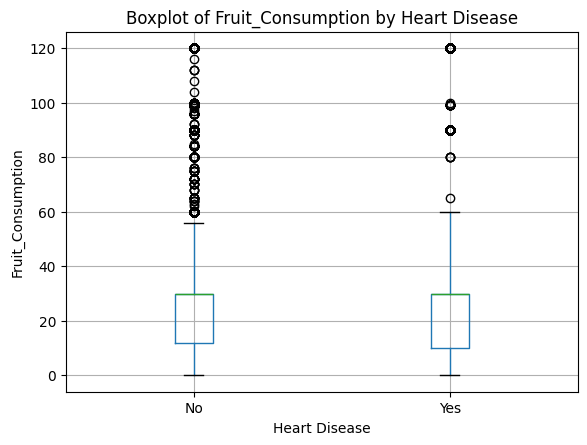

<Figure size 600x400 with 0 Axes>

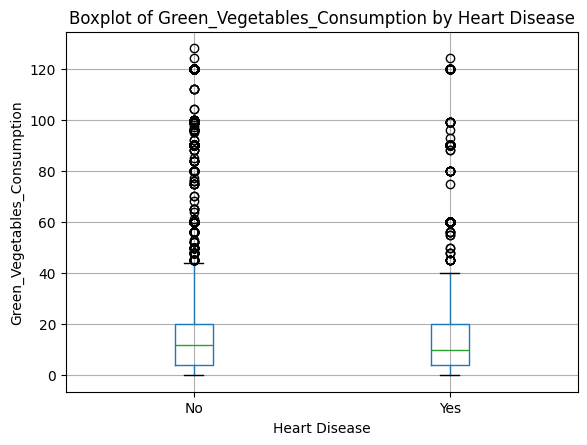

<Figure size 600x400 with 0 Axes>

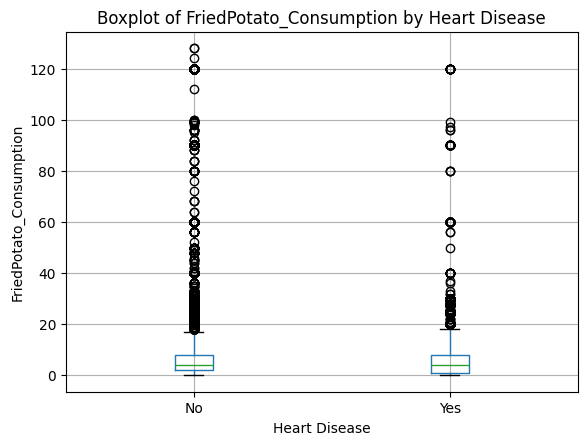

In [9]:
## Check for outliers
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if col == 'Heart_Disease':
        continue

    plt.figure(figsize=(6, 4))
    df.boxplot(column=col, by='Heart_Disease', grid=True)
    plt.title(f'Boxplot of {col} by Heart Disease')
    plt.suptitle('')
    plt.xlabel('Heart Disease')
    plt.ylabel(col)
    plt.show()


### 2.3.1.2 Understanding distribution of features

In [10]:
## Understanding distribution of features
col_y = 'Heart_Disease'
col_x = 'Age_Category'

### 2.3.2 Understanding relationship between variables

# 3. Data Preparation

## 3.1 Data Cleaning

In [11]:
## Clean data

## 3.2 Train-Test Split

In [12]:
## Split data into train set and test set


# 4. Modelling

### 4.2 Train Model

In [13]:
## Initialise and train model


# 5. Model Evaluation

In [14]:
## Evaluate model


In [15]:
## New data

## Predict


## Iterative model development


In [16]:
## Further feature engineering / feature selection